In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GATConv, HeteroConv
from torch_geometric.transforms import RandomLinkSplit

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [6]:
DATA_DIR = "/content/drive/MyDrive/drug_repurposing/data"

checkpoint = torch.load(f"{DATA_DIR}/processed/filtered_graph.pt", weights_only=False)

data = checkpoint["data"]
node_maps = checkpoint["node_maps"]
reverse_node_maps = checkpoint["reverse_node_maps"]

print(data)

HeteroData(
  Compound={ num_nodes=1441 },
  Disease={ num_nodes=134 },
  Gene={ num_nodes=18270 },
  (Compound, CtD, Disease)={ edge_index=[2, 487] },
  (Gene, GiG, Gene)={ edge_index=[2, 147164] },
  (Disease, DdG, Gene)={ edge_index=[2, 7623] },
  (Compound, CbG, Gene)={ edge_index=[2, 11571] },
  (Compound, CuG, Gene)={ edge_index=[2, 18756] },
  (Disease, DaG, Gene)={ edge_index=[2, 12623] },
  (Gene, GcG, Gene)={ edge_index=[2, 61690] },
  (Gene, Gr>G, Gene)={ edge_index=[2, 265672] },
  (Compound, CdG, Gene)={ edge_index=[2, 21102] },
  (Disease, DuG, Gene)={ edge_index=[2, 7731] }
)


In [7]:
hidden_dim = 128

for node_type in data.node_types:
    if 'x' not in data[node_type]:
        data[node_type].x = torch.randn(data[node_type].num_nodes, hidden_dim)

In [20]:
torch.manual_seed(42)

split = RandomLinkSplit(
    num_val=0.15,
    num_test=0.15,
    is_undirected=False,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    edge_types=('Compound', 'CtD', 'Disease'),
)

train_data, val_data, test_data = split(data)

In [21]:
class HeteroRGAT(nn.Module):
    def __init__(self, hidden_dim, heads=4):
        super().__init__()

        # Relation-specific GAT layers
        self.convs = nn.ModuleDict({
            str(edge_type): GATConv((-1, -1), hidden_dim, heads=heads, concat=False)
            for edge_type in data.edge_types
        })

        # Learnable relation weights ⭐
        self.rel_weights = nn.ParameterDict({
            str(edge_type): nn.Parameter(torch.tensor(1.0))
            for edge_type in data.edge_types
        })

    def forward(self, x_dict, edge_index_dict):

      out_dict = {}

      for edge_type in edge_index_dict:
          src, rel, dst = edge_type

          conv = self.convs[str(edge_type)]
          weight = self.rel_weights[str(edge_type)]

          out = conv((x_dict[src], x_dict[dst]), edge_index_dict[edge_type])
          out = F.relu(out)

          if dst not in out_dict:
              out_dict[dst] = weight * out
          else:
              out_dict[dst] = out_dict[dst] + weight * out

      # 🔥 VERY IMPORTANT: keep untouched node types
      for node_type in x_dict:
          if node_type not in out_dict:
              out_dict[node_type] = x_dict[node_type]

      return out_dict

In [22]:
def decode(z_src, z_dst):
    return torch.sum(z_src * z_dst, dim=-1)

In [23]:
device = torch.device("cpu")

model = HeteroRGAT(hidden_dim).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

criterion = nn.BCEWithLogitsLoss()

In [24]:
def train():

    model.train()
    optimizer.zero_grad()

    z_dict = model(train_data.x_dict, train_data.edge_index_dict)

    edge_store = train_data['Compound', 'CtD', 'Disease']

    src = edge_store.edge_label_index[0]
    dst = edge_store.edge_label_index[1]
    labels = edge_store.edge_label.float()

    z_src = z_dict["Compound"][src]
    z_dst = z_dict["Disease"][dst]

    preds = decode(z_src, z_dst)

    loss = criterion(preds, labels)

    loss.backward()
    optimizer.step()

    return loss.item()

In [25]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(data_split):

    model.eval()

    z_dict = model(data_split.x_dict, data_split.edge_index_dict)

    edge_store = data_split['Compound', 'CtD', 'Disease']

    src = edge_store.edge_label_index[0]
    dst = edge_store.edge_label_index[1]
    labels = edge_store.edge_label.cpu().numpy()

    z_src = z_dict["Compound"][src]
    z_dst = z_dict["Disease"][dst]

    preds = decode(z_src, z_dst).cpu().numpy()

    auc = roc_auc_score(labels, preds)
    ap = average_precision_score(labels, preds)

    return auc, ap

In [26]:
num_epochs = 50

train_losses = []
val_aucs = []
val_aps = []

for epoch in range(1, num_epochs + 1):

    loss = train()
    val_auc, val_ap = evaluate(val_data)

    train_losses.append(loss)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val AUC: {val_auc:.4f} | Val AP: {val_ap:.4f}")

Epoch 001 | Loss: 0.9177 | Val AUC: 0.5755 | Val AP: 0.5125
Epoch 002 | Loss: 0.4424 | Val AUC: 0.6193 | Val AP: 0.5404
Epoch 003 | Loss: 0.2606 | Val AUC: 0.6343 | Val AP: 0.5536
Epoch 004 | Loss: 0.1754 | Val AUC: 0.6455 | Val AP: 0.5727
Epoch 005 | Loss: 0.1207 | Val AUC: 0.6455 | Val AP: 0.5856
Epoch 006 | Loss: 0.0832 | Val AUC: 0.6455 | Val AP: 0.5927
Epoch 007 | Loss: 0.0577 | Val AUC: 0.6457 | Val AP: 0.6001
Epoch 008 | Loss: 0.0395 | Val AUC: 0.6504 | Val AP: 0.6200
Epoch 009 | Loss: 0.0271 | Val AUC: 0.6540 | Val AP: 0.6264
Epoch 010 | Loss: 0.0190 | Val AUC: 0.6557 | Val AP: 0.6314
Epoch 011 | Loss: 0.0136 | Val AUC: 0.6585 | Val AP: 0.6363
Epoch 012 | Loss: 0.0099 | Val AUC: 0.6602 | Val AP: 0.6419
Epoch 013 | Loss: 0.0073 | Val AUC: 0.6626 | Val AP: 0.6515
Epoch 014 | Loss: 0.0054 | Val AUC: 0.6611 | Val AP: 0.6515
Epoch 015 | Loss: 0.0041 | Val AUC: 0.6619 | Val AP: 0.6583
Epoch 016 | Loss: 0.0032 | Val AUC: 0.6643 | Val AP: 0.6641
Epoch 017 | Loss: 0.0026 | Val AUC: 0.66

In [27]:
test_auc, test_ap = evaluate(test_data)

print("Test AUC:", test_auc)
print("Test AP:", test_ap)

Test AUC: 0.766185025333083
Test AP: 0.7908232757975275


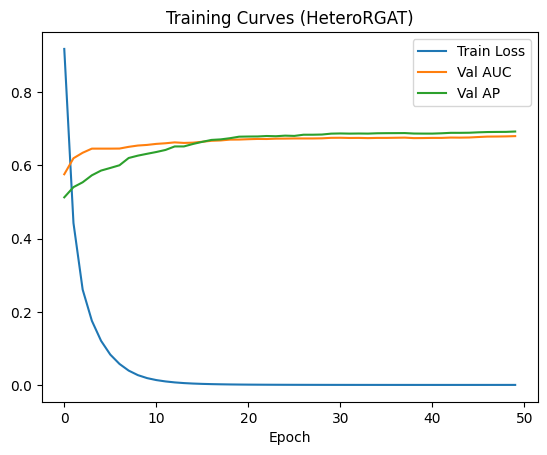

In [28]:
plt.figure()

plt.plot(train_losses, label="Train Loss")
plt.plot(val_aucs, label="Val AUC")
plt.plot(val_aps, label="Val AP")

plt.xlabel("Epoch")
plt.title("Training Curves (HeteroRGAT)")
plt.legend()

plt.show()

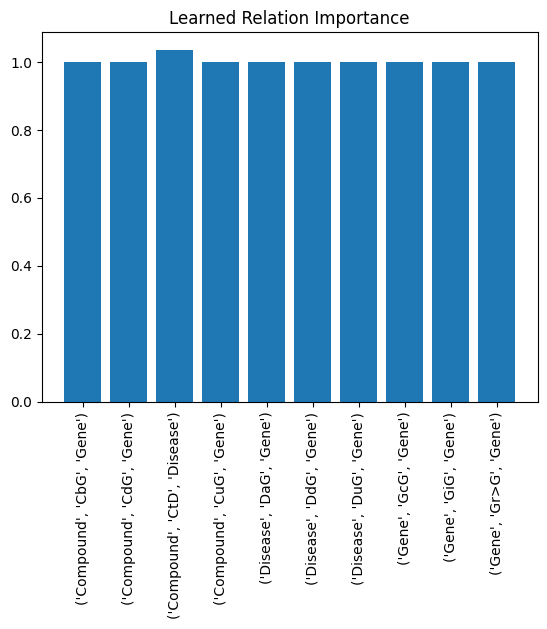

In [29]:
weights = {k: v.item() for k, v in model.rel_weights.items()}

plt.figure()
plt.bar(range(len(weights)), list(weights.values()))
plt.xticks(range(len(weights)), list(weights.keys()), rotation=90)
plt.title("Learned Relation Importance")
plt.show()

In [30]:
artifact = {
    "model_name": "hetero_rgat",
    "embedding_dim": hidden_dim,
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "val_aps": val_aps,
    "test_auc": test_auc,
    "test_ap": test_ap,
    "embeddings": model(data.x_dict, data.edge_index_dict),
    "relation_weights": weights
}

torch.save(artifact, "/content/drive/MyDrive/drug_repurposing/models/hetero_rgat_artifact.pt")

print("Saved RGAT model")

Saved RGAT model


In [32]:
rgat_artifact = torch.load(
    "/content/drive/MyDrive/drug_repurposing/models/hetero_rgat_artifact.pt",
    map_location="cpu", weights_only=False
)

z_dict = rgat_artifact["embeddings"]

comp_emb = z_dict["Compound"]
dis_emb = z_dict["Disease"]

print(comp_emb.shape, dis_emb.shape)

torch.Size([1441, 128]) torch.Size([134, 128])


In [33]:
torch.manual_seed(42)

split = RandomLinkSplit(
    num_val=0.15,
    num_test=0.15,
    is_undirected=False,
    add_negative_train_samples=False,
    edge_types=('Compound', 'CtD', 'Disease'),
)

train_data, val_data, test_data = split(data)

In [34]:
edge_store = test_data['Compound', 'CtD', 'Disease']

test_edges = edge_store.edge_label_index
test_labels = edge_store.edge_label

pos_mask = test_labels == 1
test_edges = test_edges[:, pos_mask]

print("Positive test edges:", test_edges.shape)

Positive test edges: torch.Size([2, 73])


In [35]:
def ranking_evaluation(comp_emb, dis_emb, test_edges):

    ranks = []

    for i in tqdm(range(test_edges.shape[1])):

        drug = test_edges[0, i]
        disease = test_edges[1, i]

        disease_vec = dis_emb[disease]

        scores = torch.matmul(comp_emb, disease_vec)
        scores = scores.detach().numpy()

        sorted_idx = np.argsort(-scores)

        rank = np.where(sorted_idx == drug.item())[0][0] + 1

        ranks.append(rank)

    ranks = np.array(ranks)

    return {
        "MRR": np.mean(1.0 / ranks),
        "Hits@1": np.mean(ranks <= 1),
        "Hits@5": np.mean(ranks <= 5),
        "Hits@10": np.mean(ranks <= 10),
        "Precision@10": np.mean(ranks <= 10) / 10
    }

In [36]:
rgat_results = ranking_evaluation(comp_emb, dis_emb, test_edges)

rgat_results

100%|██████████| 73/73 [00:00<00:00, 6297.49it/s]


{'MRR': np.float64(0.006243454592783846),
 'Hits@1': np.float64(0.0),
 'Hits@5': np.float64(0.0),
 'Hits@10': np.float64(0.0),
 'Precision@10': np.float64(0.0)}

In [37]:
disease_name = "Disease::DOID:0050156"

disease_idx = node_maps["Disease"][disease_name]

print(disease_idx)

0


In [38]:
def get_top_k_drugs(disease_idx, comp_emb, dis_emb, k=20):

    disease_vec = dis_emb[disease_idx]

    scores = torch.matmul(comp_emb, disease_vec)
    scores = scores.detach().numpy()

    top_k = np.argsort(-scores)[:k]

    return top_k, scores[top_k]

In [39]:
top_idx, top_scores = get_top_k_drugs(disease_idx, comp_emb, dis_emb, k=20)

drug_names = [
    reverse_node_maps["Compound"][int(i)].split("::")[-1]
    for i in top_idx
]

for i, (drug, score) in enumerate(zip(drug_names, top_scores), 1):
    print(f"{i}. {drug} | score={score:.4f}")

1. DB01205 | score=22.9310
2. DB00450 | score=17.2245
3. DB01413 | score=15.8499
4. DB00198 | score=14.8918
5. DB00217 | score=14.7760
6. DB00168 | score=14.3002
7. DB04930 | score=14.1515
8. DB00921 | score=13.7707
9. DB01262 | score=13.6910
10. DB01033 | score=13.4829
11. DB00550 | score=13.1830
12. DB00887 | score=13.0920
13. DB00703 | score=12.5722
14. DB01223 | score=12.3307
15. DB01764 | score=11.9793
16. DB00878 | score=11.9628
17. DB00152 | score=11.9249
18. DB01610 | score=11.8396
19. DB00918 | score=11.7554
20. DB08981 | score=11.4966


In [40]:
import pandas as pd

df = pd.DataFrame([rgat_results], index=["HeteroRGAT"])
df.to_csv("/content/drive/MyDrive/drug_repurposing/results/heterorgat_ranking.csv")

df

,MRR,Hits@1,Hits@5,Hits@10,Precision@10
HeteroRGAT,0.006243,0.0,0.0,0.0,0.0
